In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

In [ ]:
import pandas as pd
df=pd.read_csv("new_data.csv")
df.head()

,Make,Model,Year,Trim,MSRP,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,Aston Martin,DBX707,2024,Base,242000.0,Large,SUV,V8,Twin-Turbo,AWD,automatic,697.0,663.0,20.0
1,Audi,A3,2024,Premium w/40 TFSI,35800.0,Compact,Sedan,I4,Turbocharged,FWD,automatic,201.0,221.0,37.0
2,Audi,A3,2024,Premium w/40 TFSI,37800.0,Compact,Sedan,I4,Turbocharged,AWD,automatic,201.0,221.0,34.0
3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,Compact,Sedan,I4,Turbocharged,AWD,automatic,201.0,221.0,34.0
4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,Compact,Sedan,I4,Turbocharged,FWD,automatic,201.0,221.0,37.0


#Analysis for transforming columns

In [ ]:
df["Body Style"].value_counts()

,count
Body Style,
SUV,480
Pickup Truck,310
Sedan,261
Cargo Van,158
Coupe,107
Passenger Van,101
Convertible,76
Hatchback,45
Convertible SUV,41


/tmp/ipython-input-504128096.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Horsepower"])


np.float64(0.6416358522114559)

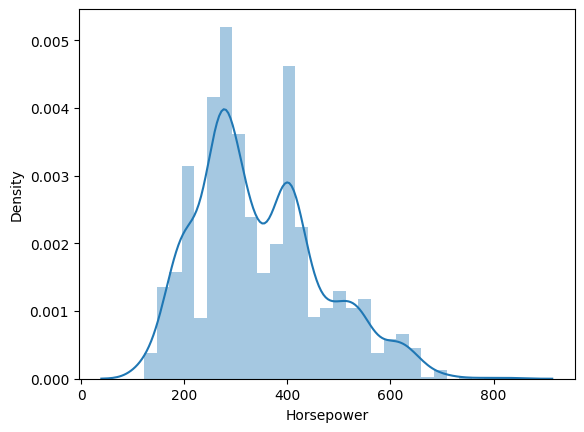

In [ ]:
import seaborn as sns
sns.distplot(df["Horsepower"])
df["Horsepower"].skew()

/tmp/ipython-input-3027567660.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Torque"])


np.float64(1.9831100525620162)

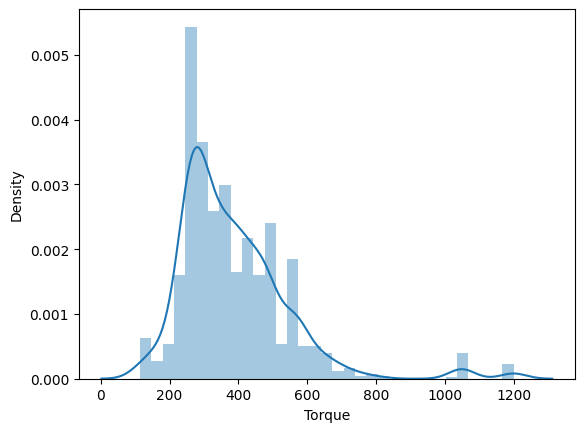

In [ ]:
sns.distplot(df["Torque"])
df["Torque"].skew()

/tmp/ipython-input-2070335158.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Highway Fuel Economy"])


np.float64(2.164823145496506)

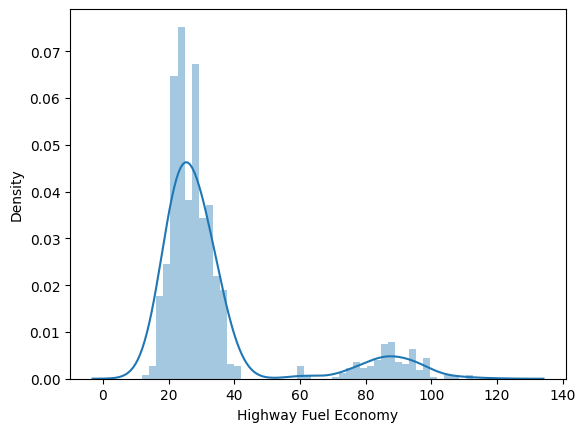

In [ ]:
sns.distplot(df["Highway Fuel Economy"])

df["Highway Fuel Economy"].skew()

In [ ]:
df["Drivetrain"].value_counts()

,count
Drivetrain,
AWD,757
RWD,433
4WD,301
FWD,119


In [ ]:
(df["Model"].value_counts().reset_index()["count"]>=25).sum()

np.int64(13)

In [ ]:
df.shape

(1610, 14)

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Trim,0
MSRP,0
Body Size,0
Body Style,0
Cylinders,165
Engine Aspiration,0
Drivetrain,0


#Workflow

In [ ]:
# #Impute Cylinders, HorsePower, Torque, Highway Fuel Economy
# #Imputation techniques-
# Categorical columns-Mode is good
#For Numerical Columns- Can use mean, median, KNN Imputer or MICE, Random Imputation, GridSearchCV can also help
#OneHotEncode the categorical columns
#Apply yeo-johnson transform to numerical columns(It helps us transform the columns based on a particular value of lambda which suits our column the best)
#Scale all the numerical columns
#Log transform (np.log1p) the target column because it has a huge range of values so it might be computationally expensive to train a linear regression model.

In [ ]:
# Converting the year column
map={
    2024:1,
    2023:0
}
df["Year"]=df["Year"].map(map)

In [ ]:
df.corr(numeric_only=True)

,Year,MSRP,Horsepower,Torque,Highway Fuel Economy
Year,1.000000,0.073089,0.079801,0.090530,0.061508
MSRP,0.073089,1.000000,0.703264,0.528913,-0.127039
Horsepower,0.079801,0.703264,1.000000,0.794974,-0.125567
Torque,0.090530,0.528913,0.794974,1.000000,0.034291
Highway Fuel Economy,0.061508,-0.127039,-0.125567,0.034291,1.000000


In [ ]:
df["Year"].value_counts()

,count
Year,
0,884
1,726


In [ ]:
df.head()

,Make,Model,Year,Trim,MSRP,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,Aston Martin,DBX707,1,Base,242000.0,Large,SUV,V8,Twin-Turbo,AWD,automatic,697.0,663.0,20.0
1,Audi,A3,1,Premium w/40 TFSI,35800.0,Compact,Sedan,I4,Turbocharged,FWD,automatic,201.0,221.0,37.0
2,Audi,A3,1,Premium w/40 TFSI,37800.0,Compact,Sedan,I4,Turbocharged,AWD,automatic,201.0,221.0,34.0
3,Audi,A3,1,Premium Plus w/40 TFSI,41400.0,Compact,Sedan,I4,Turbocharged,AWD,automatic,201.0,221.0,34.0
4,Audi,A3,1,Premium Plus w/40 TFSI,39400.0,Compact,Sedan,I4,Turbocharged,FWD,automatic,201.0,221.0,37.0


In [ ]:
df["MSRP"]=np.log1p(df["MSRP"])

In [ ]:
num_features = ["Horsepower", "Torque", "Highway Fuel Economy"]
cat_features = ["Make", "Body Size", "Body Style", "Engine Aspiration", "Drivetrain", "Transmission", "Cylinders"]

# Numeric pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_features)
], remainder='passthrough')

# Final pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["Model", "Trim", "MSRP"]),
    df["MSRP"],
    test_size=0.2,
    random_state=42
)

# Fit
pipe.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('imputer',
                                                                   KNNImputer())]),
                                                  ['Horsepower', 'Torque',
                                                   'Highway Fuel Economy']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Make', 'Body Size',
                                                   'Body Style',
                                                   'Engine Aspiration',
                                                   'Drivetrain', 'Transmission',
                                                   'Cylinders'])])),
                ('model', LinearRegression())])

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
#Training accuracy
y_train_pred= pipe.predict(X_train)
r2_score(y_train_pred,y_train)

0.9180040189279701

In [ ]:
#Training Accuracy
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


0.9368497418688502

In [ ]:
import scipy.stats as stats
from sklearn.metrics import mean_squared_error

In [ ]:
residuals = y_test - y_pred

In [ ]:
import matplotlib.pyplot as plt

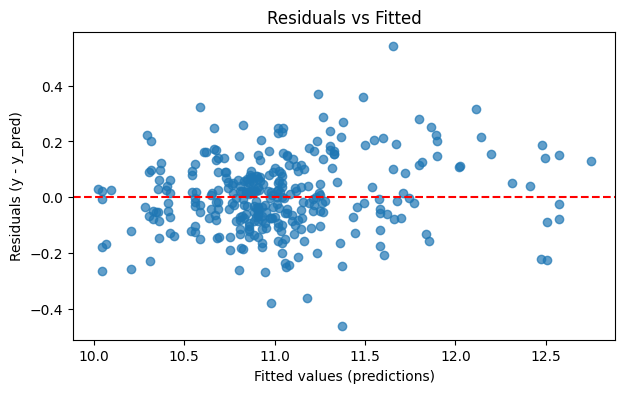

In [ ]:
#Residuals vs Fitted Plot
plt.figure(figsize=(7,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values (predictions)")
plt.ylabel("Residuals (y - y_pred)")
plt.title("Residuals vs Fitted")
plt.show()
#Residual= Error between the actual value and the predicted value
#This randomness in the shape justifies our linear regression model because the residuals dont completely depend upon the fitted values(predicted values)